In [25]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

In [27]:
DATA_DIR = Path("../../data/raw/college_experience_dataset")
print(DATA_DIR)
print(DATA_DIR.exists())

for f in sorted(DATA_DIR.rglob("*")):
    if f.is_file():
        print(f.name)

..\..\data\raw\college_experience_dataset
True
Data Dictionary.csv
demographics.csv
covid_ema.csv
Data Dictionary (COVID EMA).csv
Data Dictionary (general EMA).csv
general_ema.csv
._calllog.csv
._description.txt
calllog.csv
description.txt
._5e1d4d2718012c036ea65bfe3c80c0e7.csv
._description.txt
0ba15aa0582c5e825710d42fe3eb231d.csv
169d3212668c4eed434dafd32e33c946.csv
17fb1517cc9d7e416782bffb8edd9070.csv
1d2263527eed2a54e88d340fb8e55308.csv
212521733ea8eeff63d997dc0213c692.csv
3528757eaf1d15ee6c778eb79cd02de7.csv
35cf1abf179310dc33907d953f590366.csv
45555d3305e255895b11695c179a98cd.csv
557b44c8daf2ddb5d02313f20f2505b9.csv
5e1d4d2718012c036ea65bfe3c80c0e7.csv
73e13f8273906f7f43a077f95ec48e7d.csv
7d2c632a05bbb03ca97555d61be83c41.csv
862f10a8c357e957a59d122077b3a5ad.csv
9ffbe25e279de21de86acd54b6fa60d0.csv
a52b5e80b4c7a8e05f8cc0a16ae4ea9f.csv
a7a320d21e232075512a494c982dc17f.csv
ac70fe1f8115ac361f2023269c011c3e.csv
aeeb186fafcc356f44cae870555f4a0d.csv
bbcad50219ee8a1484b4c6f000eb4e68.csv


In [28]:
all_files = [f for f in sorted(DATA_DIR.rglob("*")) if f.is_file() and not f.name.startswith("._")]
print("Number of files:", len(all_files))

for f in all_files:
    print(f.relative_to(DATA_DIR))

Number of files: 256
Demographics\Data Dictionary.csv
Demographics\demographics.csv
EMA\covid_ema.csv
EMA\Data Dictionary (COVID EMA).csv
EMA\Data Dictionary (general EMA).csv
EMA\general_ema.csv
Raw Sensing\call_log\calllog.csv
Raw Sensing\call_log\description.txt
Raw Sensing\running_apps\0ba15aa0582c5e825710d42fe3eb231d.csv
Raw Sensing\running_apps\169d3212668c4eed434dafd32e33c946.csv
Raw Sensing\running_apps\17fb1517cc9d7e416782bffb8edd9070.csv
Raw Sensing\running_apps\1d2263527eed2a54e88d340fb8e55308.csv
Raw Sensing\running_apps\212521733ea8eeff63d997dc0213c692.csv
Raw Sensing\running_apps\3528757eaf1d15ee6c778eb79cd02de7.csv
Raw Sensing\running_apps\35cf1abf179310dc33907d953f590366.csv
Raw Sensing\running_apps\45555d3305e255895b11695c179a98cd.csv
Raw Sensing\running_apps\557b44c8daf2ddb5d02313f20f2505b9.csv
Raw Sensing\running_apps\5e1d4d2718012c036ea65bfe3c80c0e7.csv
Raw Sensing\running_apps\73e13f8273906f7f43a077f95ec48e7d.csv
Raw Sensing\running_apps\7d2c632a05bbb03ca97555d61be

In [50]:
inventory = pd.DataFrame({
    "file_name": [f.name for f in all_files],
    "relative_path": [str(f.relative_to(DATA_DIR)) for f in all_files],
    "suffix": [f.suffix.lower() for f in all_files],
    "size_bytes": [f.stat().st_size for f in all_files],
})

inventory["path_parts"] = inventory["relative_path"].str.split("\\")
inventory["top_level_group"] = inventory["path_parts"].apply(lambda x: x[0] if len(x) > 0 else None)
inventory["subgroup"] = inventory["path_parts"].apply(lambda x: x[1] if len(x) > 1 else None)

inventory.head()

,file_name,relative_path,suffix,size_bytes,path_parts,top_level_group,subgroup
0,Data Dictionary.csv,Demographics\Data Dictionary.csv,.csv,133,"[Demographics, Data Dictionary.csv]",Demographics,Data Dictionary.csv
1,demographics.csv,Demographics\demographics.csv,.csv,9088,"[Demographics, demographics.csv]",Demographics,demographics.csv
2,covid_ema.csv,EMA\covid_ema.csv,.csv,1027081,"[EMA, covid_ema.csv]",EMA,covid_ema.csv
3,Data Dictionary (COVID EMA).csv,EMA\Data Dictionary (COVID EMA).csv,.csv,1489,"[EMA, Data Dictionary (COVID EMA).csv]",EMA,Data Dictionary (COVID EMA).csv
4,Data Dictionary (general EMA).csv,EMA\Data Dictionary (general EMA).csv,.csv,2890,"[EMA, Data Dictionary (general EMA).csv]",EMA,Data Dictionary (general EMA).csv


In [51]:
top_level_counts = (
    inventory.groupby("top_level_group")
    .size()
    .reset_index(name="file_count")
    .sort_values("file_count", ascending=False)
)

top_level_counts

,top_level_group,file_count
2,Raw Sensing,245
4,Sensing,4
1,EMA,4
0,Demographics,2
3,Readme.md,1


In [52]:
suffix_counts = (
    inventory.groupby("suffix")
    .size()
    .reset_index(name="file_count")
    .sort_values("file_count", ascending=False)
)

suffix_counts

,suffix,file_count
0,.csv,251
2,.txt,4
1,.md,1


In [53]:
output_tables = Path("../../outputs/tables")
output_tables.mkdir(parents=True, exist_ok=True)

top_level_counts.to_csv(output_tables / "file_counts_by_top_level_group.csv", index=False) #svi su po 1, nepotrebno
suffix_counts.to_csv(output_tables / "file_counts_by_suffix.csv", index=False)

In [54]:
#File inventory and inspection 

def guess_role(relative_path: str) -> str:
    path_lower = relative_path.lower()
    
    if "dictionary" in path_lower:
        return "dictionary"
    if "ema" in path_lower:
        return "label_or_survey"
    if "demographics" in path_lower:
        return "metadata"
    if "raw sensing" in path_lower:
        return "sensor"
    return "unknown"

inventory["role_guess"] = inventory["relative_path"].apply(guess_role)
inventory = inventory.drop(columns=["path_parts"], errors="ignore")

inventory.sort_values(["top_level_group", "subgroup", "file_name"]).head(50)

,file_name,relative_path,suffix,size_bytes,top_level_group,subgroup,role_guess
0,Data Dictionary.csv,Demographics\Data Dictionary.csv,.csv,133,Demographics,Data Dictionary.csv,dictionary
1,demographics.csv,Demographics\demographics.csv,.csv,9088,Demographics,demographics.csv,metadata
3,Data Dictionary (COVID EMA).csv,EMA\Data Dictionary (COVID EMA).csv,.csv,1489,EMA,Data Dictionary (COVID EMA).csv,dictionary
4,Data Dictionary (general EMA).csv,EMA\Data Dictionary (general EMA).csv,.csv,2890,EMA,Data Dictionary (general EMA).csv,dictionary
2,covid_ema.csv,EMA\covid_ema.csv,.csv,1027081,EMA,covid_ema.csv,label_or_survey
5,general_ema.csv,EMA\general_ema.csv,.csv,16449907,EMA,general_ema.csv,label_or_survey
6,calllog.csv,Raw Sensing\call_log\calllog.csv,.csv,16109148,Raw Sensing,call_log,sensor
7,description.txt,Raw Sensing\call_log\description.txt,.txt,404,Raw Sensing,call_log,sensor
8,0ba15aa0582c5e825710d42fe3eb231d.csv,Raw Sensing\running_apps\0ba15aa0582c5e825710d...,.csv,8977666,Raw Sensing,running_apps,sensor
9,169d3212668c4eed434dafd32e33c946.csv,Raw Sensing\running_apps\169d3212668c4eed434da...,.csv,2645190,Raw Sensing,running_apps,sensor


In [55]:
role_counts = (
    inventory.groupby("role_guess")
    .size()
    .reset_index(name="file_count")
    .sort_values("file_count", ascending=False)
)

role_counts

,role_guess,file_count
3,sensor,245
0,dictionary,5
4,unknown,3
1,label_or_survey,2
2,metadata,1


In [56]:
inventory.to_csv(output_tables / "file_inventory.csv", index=False)
role_counts.to_csv(output_tables / "file_counts_by_role.csv", index=False)

In [57]:
# Column inventory
def load_table(path: Path):
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    elif suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    else:
        raise ValueError(f"Unsupported file type: {suffix}")

In [58]:
important_files = [
    DATA_DIR / "Demographics" / "demographics.csv",
    DATA_DIR / "Demographics" / "Data Dictionary.csv",
    DATA_DIR / "EMA" / "general_ema.csv",
    DATA_DIR / "EMA" / "Data Dictionary (general EMA).csv",
    DATA_DIR / "EMA" / "covid_ema.csv",
    DATA_DIR / "EMA" / "Data Dictionary (COVID EMA).csv",
    DATA_DIR / "Sensing" / "sensing.csv",
]

In [59]:
column_inventory_rows = []

for path in important_files:
    if not path.exists():
        print(f"Missing: {path}")
        continue
        
    df = load_table(path)
    
    for col in df.columns:
        series = df[col]
        column_inventory_rows.append({
            "file_name": path.name,
            "relative_path": str(path.relative_to(DATA_DIR)),
            "column_name": col,
            "dtype": str(series.dtype),
            "null_count": int(series.isna().sum()),
            "null_pct": float(series.isna().mean()),
            "n_unique": int(series.nunique(dropna=True)),
            "sample_value_1": str(series.dropna().iloc[0]) if series.dropna().shape[0] > 0 else None,
        })

column_inventory = pd.DataFrame(column_inventory_rows)
column_inventory.head(30)

,file_name,relative_path,column_name,dtype,null_count,null_pct,n_unique,sample_value_1
0,demographics.csv,Demographics\demographics.csv,uid,str,0,0.000000,216,3569e2f520db9014b4acc4227a6421c1
1,demographics.csv,Demographics\demographics.csv,gender,str,0,0.000000,3,both
2,demographics.csv,Demographics\demographics.csv,race,str,0,0.000000,8,white
3,Data Dictionary.csv,Demographics\Data Dictionary.csv,Variable,str,0,0.000000,3,uid
4,Data Dictionary.csv,Demographics\Data Dictionary.csv,Definition,str,0,0.000000,3,Unique user ID
5,general_ema.csv,EMA\general_ema.csv,uid,str,0,0.000000,220,1ff6d7f34acb354430e7323a35ff7703
6,general_ema.csv,EMA\general_ema.csv,day,int64,0,0.000000,1762,20170907
7,general_ema.csv,EMA\general_ema.csv,pam,float64,181969,0.837968,16,7.0
8,general_ema.csv,EMA\general_ema.csv,phq4-1,float64,181807,0.837222,4,2.0
9,general_ema.csv,EMA\general_ema.csv,phq4-2,float64,181807,0.837222,4,2.0


In [60]:
column_inventory.to_csv(output_tables / "column_inventory.csv", index=False)

In [61]:
# Inspection of specific files

general_ema_path = DATA_DIR / "EMA" / "general_ema.csv"
general_ema = load_table(general_ema_path)

print("Shape:", general_ema.shape)
display(general_ema.head())
display(general_ema.info())
display(general_ema.describe(include="all").T)


general_ema_missingness = pd.DataFrame({ # vec dobijeno u column inventory
    "column": general_ema.columns,
    "null_count": general_ema.isna().sum().values,
    "null_pct": general_ema.isna().mean().values,
    "n_unique": general_ema.nunique(dropna=True).values,
})

general_ema_missingness.sort_values("null_pct", ascending=False).head(30)


general_ema_missingness.to_csv(output_tables / "general_ema_missingness.csv", index=False)

Shape: (217155, 19)


,uid,day,pam,phq4-1,phq4-2,phq4-3,phq4-4,phq4_resp_mean,phq4_resp_median,phq4_score,social_level,sse3-1,sse3-2,sse3-3,sse3-4,sse3_resp_mean,sse3_resp_median,stress,avg_ema_spent_time
0,1ff6d7f34acb354430e7323a35ff7703,20170907,7.0,2.0,2.0,2.0,1.0,4.494280,4.409224,7.0,4.0,1.0,3.0,3.0,3.0,2.995924,2.989184,1.0,37.385698
1,1ff6d7f34acb354430e7323a35ff7703,20170908,3.0,1.0,1.0,1.0,1.0,4.634802,3.842536,4.0,2.0,2.0,3.0,3.0,3.0,6.340799,6.720536,4.0,52.117245
2,1ff6d7f34acb354430e7323a35ff7703,20170909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1ff6d7f34acb354430e7323a35ff7703,20170910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1ff6d7f34acb354430e7323a35ff7703,20170911,2.0,1.0,1.0,1.0,1.0,333.580775,2.885290,4.0,3.0,1.0,2.0,2.0,3.0,2.350849,2.317872,4.0,1351.983871


<class 'pandas.DataFrame'>
RangeIndex: 217155 entries, 0 to 217154
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   uid                 217155 non-null  str    
 1   day                 217155 non-null  int64  
 2   pam                 35186 non-null   float64
 3   phq4-1              35348 non-null   float64
 4   phq4-2              35348 non-null   float64
 5   phq4-3              35348 non-null   float64
 6   phq4-4              35348 non-null   float64
 7   phq4_resp_mean      35348 non-null   float64
 8   phq4_resp_median    35348 non-null   float64
 9   phq4_score          35348 non-null   float64
 10  social_level        35348 non-null   float64
 11  sse3-1              35348 non-null   float64
 12  sse3-2              35348 non-null   float64
 13  sse3-3              35348 non-null   float64
 14  sse3-4              35348 non-null   float64
 15  sse3_resp_mean      35348 non-null   float64


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
uid,217155,220,7e22b6d9cb821d7004409da02d95cb64,1413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,217155.0,NaN,NaN,NaN,20195506.976943,12002.566049,20170907.0,20190129.5,20191130.0,20201112.0,20220704.0
pam,35186.0,NaN,NaN,NaN,7.258938,4.33017,1.0,3.0,7.0,10.0,16.0
phq4-1,35348.0,NaN,NaN,NaN,0.698767,0.748334,0.0,0.0,1.0,1.0,3.0
phq4-2,35348.0,NaN,NaN,NaN,0.559013,0.759096,0.0,0.0,0.0,1.0,3.0
phq4-3,35348.0,NaN,NaN,NaN,0.533552,0.767423,0.0,0.0,0.0,1.0,3.0
phq4-4,35348.0,NaN,NaN,NaN,0.524216,0.767295,0.0,0.0,0.0,1.0,3.0
phq4_resp_mean,35348.0,NaN,NaN,NaN,6.662954,121.566681,-3.6405,1.060533,1.625579,2.617375,13860.450489
phq4_resp_median,35348.0,NaN,NaN,NaN,1.799358,2.515378,0.103109,0.845009,1.332035,2.016919,149.429673
phq4_score,35348.0,NaN,NaN,NaN,2.316397,2.620882,0.0,0.0,2.0,4.0,12.0


In [62]:
EXCLUDE_UIDS = [
    "c0b0998fe60a905081764378d1102494",
    "ea716dd032aaa0dcf8bfa36b1811917f",
    "ad15fc229da933fbf1fc0f92fc9b55a3",
]

def parse_dates(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["day"].astype(str), format="%Y%m%d")
    df["year_week"] = (
        df["date"].dt.isocalendar().year.astype(str) + "-W" +
        df["date"].dt.isocalendar().week.astype(str).str.zfill(2)
    )
    return df

In [63]:
# Load general_ema - completed responses only
df_ema = pd.read_csv(DATA_DIR / "EMA" / "general_ema.csv")
df_ema = parse_dates(df_ema)
df_ema = df_ema[~df_ema["uid"].isin(EXCLUDE_UIDS)]

RESPONSE_COLS = ["phq4-1","phq4-2","phq4-3","phq4-4",
                 "sse3-1","sse3-2","sse3-3","sse3-4",
                 "phq4_score","stress","social_level"]
df_ema["has_response"] = df_ema[RESPONSE_COLS].notna().any(axis=1)
df_ema_completed = df_ema[df_ema["has_response"]].copy()

# Load covid_ema - completed responses only
df_covid = pd.read_csv(DATA_DIR / "EMA" / "covid_ema.csv")
df_covid = parse_dates(df_covid)
COVID_ITEMS = [f"COVID-{i}" for i in range(1, 11)]
df_covid["has_response"] = df_covid[COVID_ITEMS].notna().any(axis=1)
df_covid_completed = df_covid[df_covid["has_response"]].copy()

# Load sensing - apply quality filter and defragment
df_sens = pd.read_csv(DATA_DIR / "Sensing" / "sensing.csv")
df_sens = df_sens.copy()
df_sens = parse_dates(df_sens)
df_sens = df_sens[df_sens["uid"].isin(df_ema["uid"].unique())]
if "quality_activity" in df_sens.columns:
    df_sens_quality = df_sens[df_sens["quality_activity"] >= 20].copy()
else:
    df_sens_quality = df_sens.copy()

print("Datasets loaded:")
print(f"  general_ema completed responses : {len(df_ema_completed):,} rows, "
      f"{df_ema_completed['uid'].nunique()} students")
print(f"  covid_ema completed responses   : {len(df_covid_completed):,} rows, "
      f"{df_covid_completed['uid'].nunique()} students")
print(f"  sensing (quality filtered)      : {len(df_sens_quality):,} rows, "
      f"{df_sens_quality['uid'].nunique()} students")

Datasets loaded:
  general_ema completed responses : 35,329 rows, 215 students
  covid_ema completed responses   : 5,614 rows, 180 students
  sensing (quality filtered)      : 175,569 rows, 215 students


In [64]:
# Verify excluded student count
all_ema_uids = set(pd.read_csv(DATA_DIR / "EMA" / "general_ema.csv")["uid"].unique())
excluded_3 = set(EXCLUDE_UIDS)
expected_217 = all_ema_uids - excluded_3
actual_215 = set(df_ema_completed["uid"].unique())
missing = expected_217 - actual_215
print(f"Expected 217 students, got {len(actual_215)}")
print(f"Students in clean set but not in completed responses: {len(missing)}")
for uid in missing:
    rows = df_ema[df_ema["uid"] == uid]
    print(f"  {uid}: {len(rows)} total rows, {rows['has_response'].sum()} with response")

Expected 217 students, got 215
Students in clean set but not in completed responses: 2
  e6d71fe4a3c10b075ae1cf51a2fe6cfd: 4 total rows, 0 with response
  df5e798581def8d477316520953b9171: 2 total rows, 0 with response


In [65]:
ema_uids   = set(df_ema_completed["uid"].unique())
covid_uids = set(df_covid_completed["uid"].unique())
sens_uids  = set(df_sens_quality["uid"].unique())

in_all_three   = ema_uids & covid_uids & sens_uids
in_ema_and_sens = ema_uids & sens_uids
only_ema       = ema_uids - sens_uids - covid_uids

print("Student-level alignment:")
print(f"  EMA students (clean)             : {len(ema_uids)}")
print(f"  COVID EMA students               : {len(covid_uids)}")
print(f"  Sensing students                 : {len(sens_uids)}")
print(f"  In EMA + sensing (pre-COVID v1)  : {len(in_ema_and_sens)}")
print(f"  In all three (v2 full overlap)   : {len(in_all_three)}")
print(f"  Only in EMA (no sensing)         : {len(only_ema)}")

Student-level alignment:
  EMA students (clean)             : 215
  COVID EMA students               : 180
  Sensing students                 : 215
  In EMA + sensing (pre-COVID v1)  : 214
  In all three (v2 full overlap)   : 180
  Only in EMA (no sensing)         : 1


In [66]:
# EMA student-weeks (one row per student per week with a completed response)
ema_weeks = (
    df_ema_completed.groupby(["uid", "year_week"])
    .size()
    .reset_index(name="ema_surveys")
)

# Sensing student-weeks (one row per student per week with >= 4 quality days)
sens_days_per_week = (
    df_sens_quality.groupby(["uid", "year_week"])
    .size()
    .reset_index(name="quality_days")
)
sens_weeks = sens_days_per_week[sens_days_per_week["quality_days"] >= 4]

# COVID student-weeks
covid_weeks = (
    df_covid_completed.groupby(["uid", "year_week"])
    .size()
    .reset_index(name="covid_surveys")
)

# Join EMA and sensing on (uid, year_week)
aligned = ema_weeks.merge(
    sens_weeks[["uid", "year_week", "quality_days"]],
    on=["uid", "year_week"],
    how="inner"
)

# Join COVID as optional
aligned_with_covid = aligned.merge(
    covid_weeks[["uid", "year_week"]],
    on=["uid", "year_week"],
    how="left",
    indicator=True
)
aligned_with_covid["has_covid"] = aligned_with_covid["_merge"] == "both"
aligned_with_covid = aligned_with_covid.drop(columns=["_merge"])

pre_covid = aligned_with_covid[aligned_with_covid["year_week"] < "2020-W12"]
post_covid = aligned_with_covid[aligned_with_covid["year_week"] >= "2020-W12"]

print("Week-level alignment (EMA + sensing inner join):")
print(f"  Total aligned student-weeks        : {len(aligned):,}")
print(f"  Unique students in aligned set     : {aligned['uid'].nunique()}")
print(f"  Pre-COVID weeks  (v1 training pool): {len(pre_covid):,}")
print(f"  Post-COVID weeks (drift period)    : {len(post_covid):,}")
print(f"  Post-COVID weeks with COVID EMA    : {aligned_with_covid[aligned_with_covid['has_covid']].shape[0]:,}")
print(f"\nDate range of aligned data:")
print(f"  First week : {aligned['year_week'].min()}")
print(f"  Last week  : {aligned['year_week'].max()}")

Week-level alignment (EMA + sensing inner join):
  Total aligned student-weeks        : 20,221
  Unique students in aligned set     : 213
  Pre-COVID weeks  (v1 training pool): 11,774
  Post-COVID weeks (drift period)    : 8,447
  Post-COVID weeks with COVID EMA    : 4,137

Date range of aligned data:
  First week : 2017-W37
  Last week  : 2022-W23


In [67]:
# After next-week shift (W -> W+1), each training example needs
# sensing from week W AND EMA label from week W+1.
# Estimate: for each aligned week W, check if week W+1 also has an EMA response.

ema_week_set = set(zip(df_ema_completed["uid"], df_ema_completed["year_week"]))

aligned["year_week_dt"] = pd.to_datetime(
    aligned["year_week"] + "-1", format="%G-W%V-%u"
)
aligned["next_week_dt"] = aligned["year_week_dt"] + pd.Timedelta(weeks=1)
aligned["next_year_week"] = (
    aligned["next_week_dt"].dt.isocalendar().year.astype(str) + "-W" +
    aligned["next_week_dt"].dt.isocalendar().week.astype(str).str.zfill(2)
)

aligned["has_next_week_ema"] = aligned.apply(
    lambda r: (r["uid"], r["next_year_week"]) in ema_week_set, axis=1
)

usable = aligned[aligned["has_next_week_ema"]]
usable_pre_covid = usable[usable["year_week"] < "2020-W12"]

print("Usable training examples after next-week shift:")
print(f"  Total usable (full dataset)    : {len(usable):,}")
print(f"  Usable pre-COVID (v1 training) : {len(usable_pre_covid):,}")
print(f"  Students represented           : {usable['uid'].nunique()}")
print(f"  Students in pre-COVID examples : {usable_pre_covid['uid'].nunique()}")
print(f"\nMean examples per student (full)     : {len(usable)/usable['uid'].nunique():.1f}")
print(f"Mean examples per student (pre-COVID): "
      f"{len(usable_pre_covid)/max(usable_pre_covid['uid'].nunique(),1):.1f}")

Usable training examples after next-week shift:
  Total usable (full dataset)    : 16,750
  Usable pre-COVID (v1 training) : 10,001
  Students represented           : 212
  Students in pre-COVID examples : 209

Mean examples per student (full)     : 79.0
Mean examples per student (pre-COVID): 47.9


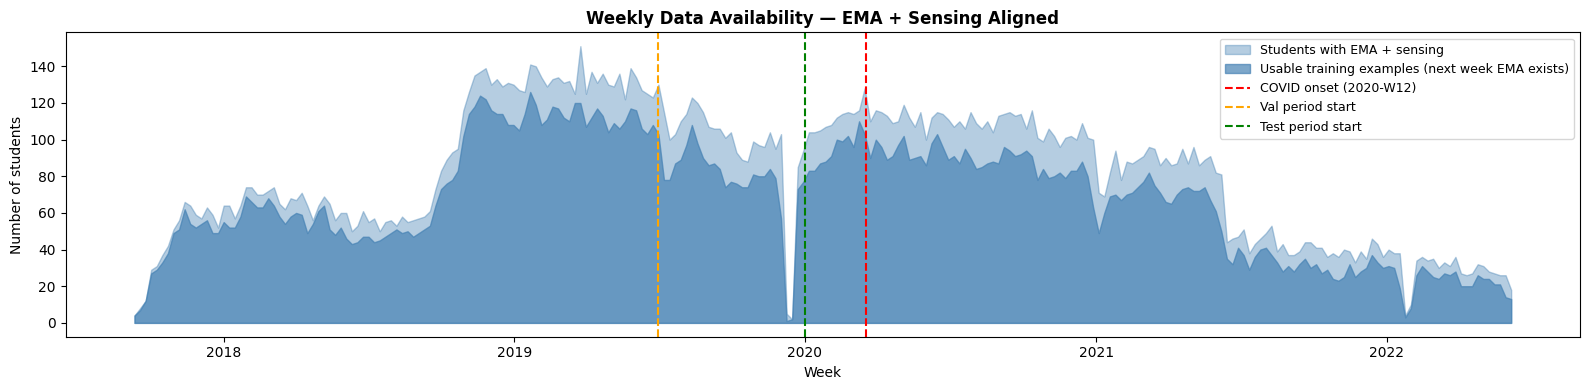

In [68]:
# Show weekly data availability over time across all students
weekly_counts = (
    aligned.groupby("year_week")
    .agg(
        n_students=("uid", "nunique"),
        n_with_next_ema=("has_next_week_ema", "sum")
    )
    .reset_index()
)
weekly_counts["week_dt"] = pd.to_datetime(
    weekly_counts["year_week"] + "-1", format="%G-W%V-%u"
)
weekly_counts = weekly_counts.sort_values("week_dt")

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(weekly_counts["week_dt"],
                weekly_counts["n_students"],
                alpha=0.4, color="steelblue", label="Students with EMA + sensing")
ax.fill_between(weekly_counts["week_dt"],
                weekly_counts["n_with_next_ema"],
                alpha=0.7, color="steelblue", label="Usable training examples (next week EMA exists)")
ax.axvline(pd.Timestamp("2020-03-18"), color="red", linestyle="--",
           linewidth=1.5, label="COVID onset (2020-W12)")
ax.axvline(pd.Timestamp("2019-07-01"), color="orange", linestyle="--",
           linewidth=1.5, label="Val period start")
ax.axvline(pd.Timestamp("2020-01-01"), color="green", linestyle="--",
           linewidth=1.5, label="Test period start")
ax.set_title("Weekly Data Availability — EMA + Sensing Aligned", fontsize=12, fontweight="bold")
ax.set_xlabel("Week")
ax.set_ylabel("Number of students")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../../outputs/figures/cross_dataset_alignment.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [69]:
summary = pd.DataFrame([
    {"Metric": "Clean EMA students", "Value": len(ema_uids)},
    {"Metric": "Sensing students (overlap)", "Value": len(sens_uids & ema_uids)},
    {"Metric": "COVID EMA students (overlap)", "Value": len(covid_uids)},
    {"Metric": "Aligned student-weeks (EMA + sensing)", "Value": len(aligned)},
    {"Metric": "Pre-COVID aligned weeks (v1 pool)", "Value": len(pre_covid)},
    {"Metric": "Post-COVID aligned weeks", "Value": len(post_covid)},
    {"Metric": "Usable training examples after shift (full)", "Value": len(usable)},
    {"Metric": "Usable training examples after shift (pre-COVID)", "Value": len(usable_pre_covid)},
    {"Metric": "Sensing ends (last date)", "Value": str(df_sens["date"].max().date())},
    {"Metric": "EMA ends (last date)", "Value": str(df_ema["date"].max().date())},
])

print("Cross-Dataset Alignment Summary:")
print(summary.to_string(index=False))
summary.to_csv("../../outputs/tables/cross_dataset_alignment_summary.csv", index=False)
print("\nSaved to outputs/tables/cross_dataset_alignment_summary.csv")

Cross-Dataset Alignment Summary:
                                          Metric      Value
                              Clean EMA students        215
                      Sensing students (overlap)        214
                    COVID EMA students (overlap)        180
           Aligned student-weeks (EMA + sensing)      20221
               Pre-COVID aligned weeks (v1 pool)      11774
                        Post-COVID aligned weeks       8447
     Usable training examples after shift (full)      16750
Usable training examples after shift (pre-COVID)      10001
                        Sensing ends (last date) 2022-06-15
                            EMA ends (last date) 2022-07-04

Saved to outputs/tables/cross_dataset_alignment_summary.csv
